In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import astropy.constants as c

import aux_functions as aux
import dsharp_opac as opacity

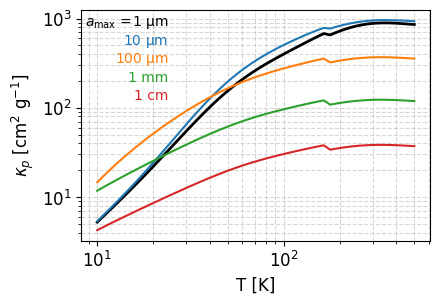

In [26]:

    plt.rc("font", size=12)
    plt.figure(figsize=(4.5,3))
    # load default opacities
    with np.load(opacity.get_datafile('default_opacities_smooth.npz')) as d:
        a_w     = d['a']
        gsca_w  = d['g']
        lam_w   = d['lam']
        k_abs_w = d['k_abs']
        k_sca_w = d['k_sca']
        k_ext_w = k_abs_w + (1 - gsca_w) * k_sca_w

    with np.load(opacity.get_datafile('icefree_opacities_smooth.npz')) as d:
        a_d      = d['a']
        gsca_d   = d['g']
        lam_d    = d['lam']
        k_abs_d  = d['k_abs']
        k_sca_d  = d['k_sca']
        k_ext_d = k_abs_d + (1 - gsca_d) * k_sca_d

    if not np.allclose(a_w, a_d):
        raise RuntimeError('size grids in opacity data do not match')

    a = a_w
    lam = lam_w
    nu = c.c.cgs.value / lam

    # default temperature grid
    
    T_grid = np.logspace(np.log10(10.0), np.log10(500.0), 50)
    k_P_pf   = np.zeros(T_grid.shape)
    k_R_pf   = np.zeros(T_grid.shape)

    # size distribution: power-law n(a) ~ a^{-q}, mass weighting -> a^(4-q)
    q = 3.5
    for ita, amax in enumerate([1e-1 * 1e-3, 1e-1 * 1e-2, 1e-1 * 1e-1, 1e-1, 1]):  # cm
        power_law = a**(4.0 - q)
        power_law[a > amax] = 0.0
        power_law = power_law / power_law.sum()


        k_abs_p_w = (k_abs_w.T * power_law[None, :]).sum(1)
        k_ext_p_w = (k_ext_w.T * power_law[None, :]).sum(1)

        # the dry ones

        k_abs_p_d = (k_abs_d.T * power_law[None, :]).sum(1)
        k_ext_p_d = (k_ext_d.T * power_law[None, :]).sum(1)

        for it, _T in enumerate(T_grid):
            Bnu    = aux.planck_B_nu(nu, _T)
            dBnudT = aux.planck_dBnu_dT(nu, _T)
            B      = np.trapezoid(Bnu, x=nu)
            dBdT   = np.trapezoid(dBnudT, x=nu)

            if _T < 170:
                k_P_pf[it]  = np.trapezoid(Bnu * k_abs_p_w, x=nu) / B
                k_R_pf[it]  = dBdT / np.trapezoid(dBnudT / k_ext_p_w, x=nu)
            else:
                k_P_pf[it]  = np.trapezoid(Bnu * k_abs_p_d, x=nu) / B
                k_R_pf[it]  = dBdT / np.trapezoid(dBnudT / k_ext_p_d, x=nu)


        if ita == 0:
            plt.plot(T_grid, k_P_pf, 'k-', linewidth=2)
            plt.text(0.01, 0.93-ita*0.08, r'$a_{\rm max}$ =', fontsize=10,
                  transform=plt.gca().transAxes)
        else:
            plt.plot(T_grid, k_P_pf, )
        plt.text(0.25, 0.93-ita*0.08,  [r'1 $\rm \mu m$',
                                                            r'10 $\rm \mu m$',
                                                            r'100 $\rm \mu m$',
                                                            '1 mm', 
                                                            '1 cm', ][ita], fontsize=10,
                    ha='right',
                  transform=plt.gca().transAxes,
                  color=['k', 'C0', 'C1', 'C2', 'C3', 'C4'][ita])
    plt.loglog()
    plt.grid(True, which='both', ls='--', alpha=0.5)
    plt.xlabel("T [K]")
    plt.ylabel(r"$\kappa_p$ [cm$^2$ g$^{-1}$]")
    plt.savefig("kappa_p.pdf", bbox_inches='tight', transparent=True)